# Phishing Email Detection with RoBERTa: Overview & Workflow

---
**Project Structure Overview**

- **Dataset:** All email data is loaded from `Phishing_Email.csv`.
- **Model:** The fine-tuned RoBERTa model is stored in the `roberta-model-xai` directory.
- **XAI Reports:** After step 10 (automated explainable analysis), the final generated explainability reports are saved in the `xai_reports` directory.

---

This notebook provides a step-by-step guide to phishing email detection using the RoBERTa model.

## Workflow Summary

> Project Proposal (1 ~ 8)
1. **Library Imports and Environment Setup**  
   - Import essential Python libraries such as pandas, numpy, torch, scikit-learn, matplotlib, transformers, and tqdm.
   - Fix random seeds for random, numpy, and torch to ensure full reproducibility of experiments.

2. **Data Loading and Preprocessing**  
   - Load the phishing email dataset.
   - Remove unnecessary columns, handle missing and duplicate entries.
   - Convert data types and encode labels ("Safe Email" as 0, "Phishing Email" as 1).

3. **Data Splitting**  
   - Split the preprocessed data into training, validation, and test sets using stratified sampling to maintain class balance.

4. **Tokenization and Dataset Preparation**  
   - Tokenize email texts using the RoBERTa tokenizer.
   - Define a custom PyTorch Dataset class to prepare the data for model input.

5. **DataLoader Construction**  
   - Create DataLoaders for training, validation, and test datasets to enable efficient batch processing.

6. **Model Initialization and Training Setup**  
   - Load the RobertaForSequenceClassification model, set up the device (CPU/MPS), optimizer (AdamW), and learning rate scheduler.

7. **Model Training and Validation**  
   - Train the model on the training set and monitor performance on the validation set.
   - Record training loss and validation accuracy for each epoch, and apply Early Stopping to save the best model.

8. **Model Evaluation**  
   - Evaluate the model on the test set.
   - Calculate and visualize various metrics such as accuracy, F1-score, classification report, and confusion matrix.

> FINAL Project (9 ~ 10)
9. **Applying Explainability with Layer Integrated Gradients (LIG)**
   - Apply Captum's LIG technique to the trained RoBERTa model to visually analyze the contribution of input tokens to predictions.
   - For a given input text, compute token-level attribution scores and visualize them (e.g., bar charts, HTML) to understand the model's prediction rationale.
   - The RoBERTaLIGAnalyzer class initializes the tokenizer, embedding layer, and LIG object, and performs analysis and visualization.

10. **Explainable RoBERTa + LIG-based Automated Phishing Detection System**
   - Monitor real-time emails via the Gmail API, and for each email, automatically perform RoBERTa + LIG analysis, generate a natural language report using GPT-4o, and send Slack notifications.
   - The EnhancedRoBERTaXAI class encapsulates the core logic for LIG analysis, GPT-based report generation, HTML visualization, and risk signal analysis.
   - The PhishingXAIAnalyzer class streamlines the entire automation flow into a single method (analyze_and_report) for easy execution.

--- 

# RoBERTa 기반 피싱 이메일 탐지: 개요 및 워크플로우

---
**프로젝트 구조 안내**

- **데이터셋:** 모든 이메일 데이터는 `Phishing_Email.csv` 파일에서 불러옵니다.
- **모델:** 파인튜닝된 RoBERTa 모델은 `roberta-model-xai` 디렉토리에 저장되어 있습니다.
- **XAI 보고서:** 10번 과정(자동 설명가능 분석) 이후 최종 생성된 설명 보고서는 `xai_reports` 디렉토리에 저장됩니다.

---

이 노트북은 RoBERTa 기반 피싱 이메일 탐지의 전체 실습 과정을 단계별로 안내합니다.

## 전체 워크플로우 요약

> Project Proposal (1 ~ 8)
1. **라이브러리 임포트 및 환경 설정**  
   - pandas, numpy, torch, scikit-learn, matplotlib, transformers, tqdm 등 필요한 파이썬 라이브러리를 임포트합니다.
   - random, numpy, torch의 시드를 고정하여 실험의 재현성을 보장합니다.

2. **데이터 불러오기 및 전처리**  
   - 피싱 이메일 데이터셋을 불러옵니다.
   - 불필요한 열을 제거하고, 결측치와 중복 데이터를 처리합니다.
   - 데이터 타입을 변환하고, 레이블(정상/피싱)을 인코딩합니다.  
     (이 노트북에서는 "Safe Email"을 0, "Phishing Email"을 1으로 인코딩합니다.)

3. **데이터 분할**  
   - 전처리된 데이터를 학습, 검증, 테스트 세트로 stratified sampling(계층적 샘플링)을 통해 분할하여 클래스 불균형을 방지합니다.

4. **토크나이징 및 데이터셋 준비**  
   - RoBERTa 토크나이저를 사용해 이메일 텍스트를 토크나이즈합니다.
   - PyTorch Dataset 클래스를 정의하여 모델 입력에 맞는 데이터셋을 준비합니다.

5. **DataLoader 구성**  
   - 학습, 검증, 테스트 데이터셋에 대해 DataLoader를 생성하여 배치 단위로 데이터를 효율적으로 처리할 수 있도록 합니다.

6. **모델 초기화 및 학습 환경 설정**  
   - RobertaForSequenceClassification 모델을 불러오고, 디바이스(CPU/MPS), 옵티마이저(AdamW), 러닝레이트 스케줄러 등을 설정합니다.

7. **모델 학습 및 검증**  
   - 학습 데이터로 모델을 학습시키고, 검증 데이터로 성능을 모니터링합니다.
   - 에폭별로 학습 손실과 검증 정확도를 기록하며, Early Stopping을 적용해 최적 모델을 저장합니다.

8. **모델 평가**  
   - 테스트 데이터로 모델을 평가합니다.
   - 정확도(Accuracy), F1-score, 분류 리포트, 혼동행렬(Confusion Matrix) 등 다양한 지표를 산출하고 시각화합니다.

> Final Project (9 ~ 10) 
9. **Layer Integrated Gradients (LIG)를 활용한 설명가능성 적용A**
   - 학습된 RoBERTa 모델에 Captum의 LIG 기법을 적용해 입력 토큰의 예측 기여도를 시각적으로 분석합니다.
   - 입력 텍스트에 대해 토큰 단위 기여도를 계산하고, 이를 시각화(막대그래프, HTML 등)하여 모델의 예측 근거를 확인할 수 있습니다.
   - RoBERTaLIGAnalyzer 클래스를 통해 토크나이저, 임베딩 레이어, LIG 객체를 초기화하고, 분석 및 시각화를 수행합니다.

10. **설명 가능한 RoBERTa + LIG 기반 자동 피싱 탐지 시스템**
   - Gmail API를 통해 실시간 이메일을 모니터링하고, 각 메일에 대해 RoBERTa + LIG 분석, GPT-4o 기반 자연어 보고서 생성, Slack 알림 전송 등을 자동으로 수행합니다.
   - EnhancedRoBERTaXAI 클래스가 LIG 분석과 GPT 기반 보고서 생성, HTML 시각화, 위험 신호 분석 등의 핵심 로직을 캡슐화합니다.
   - PhishingXAIAnalyzer 클래스가 전체 자동화 흐름을 단일 메서드(analyze_and_report)로 구성하여 실행을 간편화합니다.


In [1]:
MODEL_DIR = "./roberta-model-xai" # TODO saved model directory

In [2]:
import random
import numpy as np
import pandas as pd
import os

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

from transformers import RobertaTokenizer, RobertaForSequenceClassification, RobertaConfig, get_linear_schedule_with_warmup
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
elif torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)


## 2. Data Loading and Preprocessing

In this section, we load the original dataset for phishing email detection and preprocess it for analysis and model training.

1. **Load Data:**  
   Read the `Phishing_Email.csv` file into a pandas DataFrame.
2. **Remove Unnecessary Columns:**  
   If the `"Unnamed: 0"` column (automatically generated during saving/loading) exists, drop it.
3. **Remove Missing and Duplicate Entries:**  
   Ensure data reliability by removing all missing values and duplicate rows.
4. **Convert Data Types:**  
   Convert the email body (`"Email Text"`) to string type for proper text processing.
5. **Label Encoding:**  
   Convert the email type (`"Email Type"`) to numeric labels:  
   `"Safe Email"` as 0 and `"Phishing Email"` as 1 for model training.

---

## 2. 데이터 불러오기 및 전처리

본 섹션에서는 피싱 이메일 탐지 실험에 사용할 원본 데이터를 불러오고, 분석 및 모델 학습에 적합하도록 전처리합니다.

1. **데이터 불러오기:**  
   `Phishing_Email.csv` 파일을 pandas DataFrame으로 읽어옵니다.
2. **불필요한 열 제거:**  
   데이터 저장 및 불러오기 과정에서 자동 생성된 `"Unnamed: 0"` 열이 존재할 경우 이를 삭제합니다.
3. **결측치 및 중복 제거:**  
   데이터의 신뢰성을 높이기 위해 결측치와 중복 행을 모두 제거합니다.
4. **데이터 타입 변환:**  
   이메일 본문(`"Email Text"`)을 문자열 타입으로 변환하여 텍스트 처리에 적합하게 만듭니다.
5. **레이블 인코딩:**  
   이메일 유형(`"Email Type"`)을 모델 학습에 사용할 수 있도록  
   `"Safe Email"`은 0, `"Phishing Email"`은 1으로 변환합니다.


In [3]:
df = pd.read_csv("./Phishing_Email.csv") 

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df = df.dropna().drop_duplicates()
df["Email Text"] = df["Email Text"].astype(str)
df["Email Type"] = df["Email Type"].map({"Phishing Email": 1, "Safe Email": 0})

## 3. Data Splitting

In this step, the preprocessed dataset is split into training, validation, and test sets.  
First, 60% of the data is allocated for training, and the remaining 40% is set aside as a temporary set.  
The temporary set is then evenly divided into validation and test sets, each comprising 20% of the total data.  
The `stratify` option ensures that class distributions are preserved in each split, and `random_state` is set for reproducibility.

---

## 3. 데이터 분할

본 단계에서는 전처리된 전체 데이터셋을 학습, 검증, 테스트 세트로 분할합니다.  
먼저, 전체 데이터의 60%를 학습용(train)으로, 나머지 40%를 임시 세트(temp)로 분할합니다.  
이후 임시 세트를 다시 50:50으로 나누어 검증용(validation)과 테스트용(test) 세트를 각각 전체 데이터의 20%씩 할당합니다.  
각 분할 과정에서 클래스 비율이 유지되도록 `stratify` 옵션을 사용하였으며, 재현성을 위해 `random_state`를 고정하였습니다.


In [4]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["Email Text"].tolist(), df["Email Type"].tolist(),
    test_size=0.4, random_state=SEED, stratify=df["Email Type"]
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.5, random_state=SEED, stratify=temp_labels
)

## 4. Model Preparation and Custom Dataset Construction

In this section, we prepare the RoBERTa model and tokenizer for the phishing email detection task. 
We use the "roberta-base" pre-trained model and its corresponding tokenizer from Hugging Face's Transformers library. 
The maximum sequence length for tokenization is set to 128 tokens to ensure consistent input size for the model.

To efficiently handle our email dataset, we define a custom PyTorch `Dataset` class named `MailDataset`. 
This class takes in the email texts and their labels, applies the tokenizer to each text, and formats the data for model training and evaluation. 
The `__getitem__` method ensures that each sample is tokenized, padded or truncated to the specified maximum length, and converted into PyTorch tensors, including the label.

This modular approach allows seamless integration with PyTorch's DataLoader for efficient batch processing during training and evaluation.

---

## 4. 모델 준비 및 커스텀 데이터셋 구성

본 단계에서는 피싱 이메일 탐지 작업을 위해 RoBERTa 모델과 토크나이저를 준비합니다. 
Hugging Face Transformers 라이브러리의 "roberta-base" 사전학습 모델과 해당 토크나이저를 사용합니다. 
입력 시퀀스의 최대 길이는 128 토큰으로 설정하여 모델 입력 크기를 통일합니다.

이메일 데이터셋을 효율적으로 처리하기 위해 PyTorch의 `Dataset` 클래스를 상속받은 커스텀 클래스 `MailDataset`을 정의합니다. 
이 클래스는 이메일 텍스트와 레이블을 받아 각 텍스트에 토크나이저를 적용하고, 학습 및 평가에 적합한 형태로 데이터를 변환합니다. 
`__getitem__` 메서드는 각 샘플을 지정된 최대 길이로 토크나이즈, 패딩 또는 잘라내기 처리하며, 레이블을 포함해 모두 PyTorch 텐서로 반환합니다.

이러한 구조는 PyTorch의 DataLoader와 연동하여 학습 및 평가 시 효율적인 배치 처리를 가능하게 합니다.


In [5]:

model_name = "roberta-base"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
max_len = 128 

class MailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt'
        )
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(label, dtype=torch.long)
        return item

## 5. Dataset and DataLoader Construction

In this section, we prepare the datasets and data loaders required for training, validation, and testing in the phishing email detection task using the RoBERTa model.
The previously defined `MailDataset` class is instantiated for each data split (train, validation, test), receiving the corresponding texts, labels, tokenizer, and maximum sequence length.

For each dataset, a DataLoader is created. The training DataLoader shuffles the data to improve model generalization, and all DataLoaders use a fixed batch size for efficient processing.
To ensure reproducibility, a worker initialization function is set to fix the random seed for each worker.
This setup enables consistent and efficient batch processing during model training and evaluation.

---

## 5. 피싱 이메일 탐지를 위한 데이터셋 및 DataLoader 구성

이 섹션에서는 RoBERTa 모델을 활용한 피싱 이메일 탐지 과제의 학습, 검증, 테스트 데이터셋과 DataLoader를 준비합니다.
앞서 정의한 `MailDataset` 클래스를 각 데이터 분할(학습, 검증, 테스트)에 대해 인스턴스화하며, 각 데이터셋에는 해당 텍스트, 레이블, 토크나이저, 최대 시퀀스 길이를 전달합니다.

각 데이터셋에 대해 DataLoader를 생성합니다. 학습용 DataLoader는 데이터 셔플을 통해 모델의 일반화 성능을 높이고, 모든 DataLoader는 고정된 배치 크기를 사용하여 효율적인 처리를 보장합니다.
재현성을 위해 각 워커마다 난수 시드를 고정하는 worker initialization 함수를 지정하였습니다.
이러한 구성은 모델 학습 및 평가 과정에서 일관되고 효율적인 배치 처리를 가능하게 합니다.


In [6]:
batch_size = 16 

train_dataset = MailDataset(train_texts, train_labels, tokenizer, max_len)
val_dataset = MailDataset(val_texts, val_labels, tokenizer, max_len)
test_dataset = MailDataset(test_texts, test_labels, tokenizer, max_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, worker_init_fn=lambda worker_id: np.random.seed(SEED + worker_id))
val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=0, worker_init_fn=lambda worker_id: np.random.seed(SEED + worker_id))
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=0, worker_init_fn=lambda worker_id: np.random.seed(SEED + worker_id))

## 6. Model Initialization and Training Setup

In this section, we initialize the RoBERTa model for sequence classification, configure the training device, and set up the optimizer and learning rate scheduler for model training. The model is loaded with pre-trained weights and adapted for binary classification. The training will run for a fixed number of epochs, and the AdamW optimizer is used with a low learning rate to ensure stable fine-tuning. The learning rate scheduler is configured to linearly decrease the learning rate throughout training, which helps improve convergence and generalization.

- The device is CPU.
- The RoBERTa model is loaded with two output labels for binary classification and moved to the selected device.
- The optimizer (AdamW) and learning rate scheduler are set up for efficient and stable training.
- `output_attentions=True` is set in the model configuration to enable attention outputs for XAI (explainable AI) purposes.

This setup ensures that the model is properly configured for the phishing email detection task and is ready for the subsequent training and evaluation steps.

---

## 6. 모델 초기화 및 학습 환경 설정

이 섹션에서는 시퀀스 분류를 위한 RoBERTa 모델을 초기화하고, 학습에 사용할 디바이스와 옵티마이저, 러닝레이트 스케줄러를 설정합니다. 사전학습된 RoBERTa 모델을 불러와 이진 분류에 맞게 구성하며, 학습은 고정된 에폭 수만큼 진행됩니다. AdamW 옵티마이저를 낮은 학습률로 설정하여 파인튜닝의 안정성을 높이고, 러닝레이트 스케줄러는 학습 과정에서 선형적으로 학습률을 감소시켜 모델의 수렴과 일반화 성능을 향상시킵니다.

- 디바이스는 CPU를 사용합니다.
- RoBERTa 모델은 이진 분류를 위해 두 개의 출력 레이블로 불러오고, 선택된 디바이스로 이동시킵니다.
- 옵티마이저(AdamW)와 러닝레이트 스케줄러를 설정하여 효율적이고 안정적인 학습 환경을 구성합니다.
- XAI(설명 가능한 인공지능)를 위해 모델 설정에서 `output_attentions=True`를 적용하여 어텐션 정보를 출력하도록 하였습니다.

이러한 설정을 통해 피싱 이메일 탐지 과제에 적합한 모델 학습 환경을 구축하고, 이후의 학습 및 평가 단계가 원활하게 진행될 수 있도록 준비합니다.

In [7]:
device = torch.device("cpu")

print(f"Using device: {device}")

config = RobertaConfig.from_pretrained(model_name, num_labels=2, output_attentions=True) # output_attentions=True for XAI
model = RobertaForSequenceClassification.from_pretrained(model_name, config=config)
model = model.to(device)

epochs = 10 # epochs
optimizer = AdamW(model.parameters(), lr=1e-5) # AdamW optimizer with learning rate 1e-5
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0, num_training_steps=total_steps
)


Using device: cpu


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 7. Model Training, Validation and Save

In this section, we train and validate the RoBERTa model for phishing email detection. The training loop iterates over a fixed number of epochs (`epoch = 10`), performing both training and validation at each epoch. During training, the model parameters are updated using the AdamW optimizer and a linear learning rate scheduler. After each epoch, the model is evaluated on the validation set to monitor its generalization performance. Early stopping (`patient = 2`) is implemented to prevent overfitting by halting training if the validation accuracy does not improve for a set number of epochs. The best-performing model weights are saved for later use, and the best model is stored as a checkpoint file.

**Key steps in this section:**
- Training the model on the training dataset and tracking the loss.
- Evaluating the model on the validation dataset and calculating accuracy.
- Applying early stopping based on validation accuracy to ensure optimal model selection.
- Saving the best model checkpoint for future evaluation or deployment (the best model is saved).

This approach ensures robust and reproducible training, leading to a well-generalized model for phishing email detection.

---

## 7. 모델 학습, 검증 및 저장 

이 섹션에서는 피싱 이메일 탐지를 위한 RoBERTa 모델의 학습과 검증을 수행합니다. 학습 루프는 지정된 에폭 수(`epoch = 10`)만큼 반복되며, 각 에폭마다 학습과 검증을 모두 진행합니다. 학습 단계에서는 AdamW 옵티마이저와 선형 러닝레이트 스케줄러를 사용하여 모델 파라미터를 업데이트합니다. 각 에폭이 끝난 후에는 검증 데이터셋을 이용해 모델의 일반화 성능을 평가합니다. 검증 정확도가 일정 에폭 동안 향상되지 않으면 조기 종료(Early Stopping, `patient = 2`)를 적용하여 과적합을 방지합니다. 가장 성능이 좋은 모델의 가중치는 저장되어 이후 평가나 배포에 활용되며, 최적의 모델이 체크포인트 파일로 저장됩니다.

**이 섹션의 주요 단계:**
- 학습 데이터셋을 이용한 모델 학습 및 손실 추적
- 검증 데이터셋을 이용한 모델 평가 및 정확도 계산
- 검증 정확도 기반 조기 종료 적용으로 최적 모델 선택
- 최적 모델 체크포인트 저장(최고 성능 모델이 저장됨)

이러한 방식은 견고하고 재현 가능한 학습을 보장하며, 피싱 이메일 탐지에 적합한 일반화된 모델을 얻을 수 있도록 합니다.


In [ ]:
train_losses, val_accuracies = [], []
best_val_acc = 0
patience = 2 
patience_counter = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0
    progress_bar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Training]")
    for batch in progress_bar_train:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * batch["input_ids"].size(0)
        progress_bar_train.set_postfix({'loss': loss.item()})
    avg_train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    model.eval()
    preds, true_labels = [], []
    progress_bar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Validation]")
    with torch.no_grad():
        for batch in progress_bar_val:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            preds += torch.argmax(logits, dim=1).cpu().tolist()
            true_labels += batch["labels"].cpu().tolist()
    acc = accuracy_score(true_labels, preds)
    val_accuracies.append(acc)
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} - Val Acc: {acc*100:.2f}%")

    if acc > best_val_acc:
        best_val_acc = acc
        patience_counter = 0
        model.save_pretrained(MODEL_DIR) # save the best model (MODEL_DIR = "roberta-model-xai")
        tokenizer.save_pretrained(MODEL_DIR) # save the tokenizer
        print(f"Best model saved to {MODEL_DIR}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered!")
            break

## 8. Evaluation of Fine-tuned RoBERTa on Test Set

In this section, we evaluate the performance of the fine-tuned RoBERTa model on the test dataset.
The model weights are loaded from the best checkpoint saved during training. The model is set to evaluation mode to ensure that layers like dropout and batch normalization behave appropriately.
We then iterate over the test data, making predictions for each batch without updating gradients.
After collecting all predictions and true labels, we compute key evaluation metrics: accuracy, F1 score, and a detailed classification report.
Finally, we visualize the confusion matrix to provide a clear overview of the model's classification performance between "phishing" and "safe" emails.

---

## 8. 테스트셋에서 RoBERTa 성능 평가

이 섹션에서는 학습이 완료된 RoBERTa 모델을 테스트 데이터셋에서 평가합니다.
학습 과정에서 저장한 최적의 체크포인트로부터 모델 가중치를 불러오고, 평가 모드로 전환하여 드롭아웃 및 배치 정규화 계층이 올바르게 동작하도록 합니다.
이후 테스트 데이터를 배치 단위로 순회하며, 기울기 계산 없이 예측을 수행합니다.
모든 예측값과 실제 라벨을 수집한 뒤, 정확도, F1 점수, 그리고 상세 분류 리포트 등 주요 평가 지표를 산출합니다.
마지막으로, 혼동 행렬을 시각화하여 "phishing"과 "safe" 이메일 분류 성능을 한눈에 확인할 수 있도록 합니다.



Testing:   0%|          | 0/220 [00:00<?, ?it/s]

RobertaSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.



[RoBERTa] Test Results

Accuracy : 0.9863169897377423
F1 Score (Phishing class=1) : 0.9817073170731707

Classification Report:
               precision    recall  f1-score   support

    Safe (0)       0.99      0.99      0.99      2197
Phishing (1)       0.98      0.98      0.98      1311

    accuracy                           0.99      3508
   macro avg       0.99      0.99      0.99      3508
weighted avg       0.99      0.99      0.99      3508



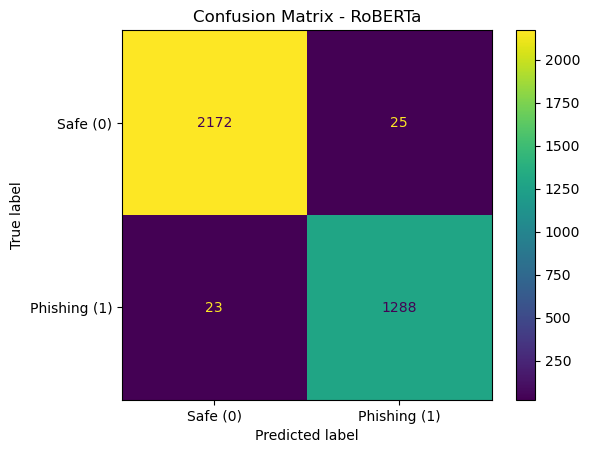

In [8]:
config = RobertaConfig.from_pretrained(MODEL_DIR) 
model = RobertaForSequenceClassification.from_pretrained(MODEL_DIR, config=config)
model = model.to(device)
tokenizer = RobertaTokenizer.from_pretrained(MODEL_DIR)

model.eval()
test_preds, test_true_labels = [], []
progress_bar_test = tqdm(test_loader, desc="Testing")
with torch.no_grad():
    for batch in progress_bar_test:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        test_preds += torch.argmax(logits, dim=1).cpu().tolist()
        test_true_labels += batch["labels"].cpu().tolist()

print("\n[RoBERTa] Test Results\n")
print("Accuracy :", accuracy_score(test_true_labels, test_preds))
print("F1 Score (Phishing class=1) :", f1_score(test_true_labels, test_preds, pos_label=1))
print("\nClassification Report:\n", classification_report(test_true_labels, test_preds, target_names=["Safe (0)", "Phishing (1)"]))

cm = confusion_matrix(test_true_labels, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Safe (0)", "Phishing (1)"])
disp.plot()
plt.title("Confusion Matrix - RoBERTa")
plt.show()

## 9. Explainability with Layer Integrated Gradients (LIG) on RoBERTa

This section presents an explainable AI (XAI) implementation using **Layer Integrated Gradients (LIG)** on a fine-tuned RoBERTa model for binary classification. The goal is to understand which input tokens most influenced the model's prediction, enhancing interpretability for tasks such as phishing email detection.

### Model Initialization

The RoBERTa model and tokenizer are loaded either from a local directory. The model is configured for binary classification and set to evaluation mode on CPU to ensure consistent inference behavior.

### Analyzer Class: `RoBERTaLIGAnalyzer`

This class encapsulates all components required for interpretability via LIG:

* **Initialization**: Sets up the tokenizer, model, embedding layer, and Captum's `LayerIntegratedGradients`.
* **`analyze()`**: Runs the LIG attribution computation over input tokens and returns:

  * tokens,
  * token-wise attribution scores,
  * predicted class and its confidence.
* **Visualization Methods**:

  * `plot_lig()` renders a token-wise attribution bar chart.
  * `show_lig_html()` displays token attributions in a color-coded HTML format.
  * `plot_topk_lig()` and `show_topk_lig_html()` highlight only the top-K contributing tokens.

---

## 9. RoBERTa에서 Layer Integrated Gradients (LIG)를 활용한 설명가능성

이 섹션에서는 이진 분류를 위해 파인튜닝된 RoBERTa 모델에 **Layer Integrated Gradients (LIG)**를 적용한 설명 가능한 인공지능(XAI) 구현을 소개합니다. 목표는 입력 토큰 중 어떤 부분이 모델의 예측에 가장 큰 영향을 미쳤는지 파악하여, 피싱 이메일 탐지와 같은 작업에서 해석 가능성을 높이는 것입니다.

### 모델 초기화

RoBERTa 모델과 토크나이저는 로컬 디렉토리에서 불러옵니다. 모델은 이진 분류에 맞게 설정되며, 일관된 추론을 위해 CPU에서 평가 모드로 전환됩니다.

### 분석기 클래스: `RoBERTaLIGAnalyzer`

이 클래스는 LIG 기반 해석에 필요한 모든 구성요소를 캡슐화합니다:

* **초기화**: 토크나이저, 모델, 임베딩 레이어, Captum의 `LayerIntegratedGradients`를 설정합니다.
* **`analyze()`**: 입력 토큰에 대해 LIG 기여도 계산을 수행하고 다음을 반환합니다:

  * 토큰 목록,
  * 토큰별 기여도 점수,
  * 예측된 클래스와 그 신뢰도.
* **시각화 메서드**:

  * `plot_lig()`는 토큰별 기여도 막대그래프를 그립니다.
  * `show_lig_html()`은 토큰 기여도를 색상으로 구분된 HTML 형식으로 보여줍니다.
  * `plot_topk_lig()` 및 `show_topk_lig_html()`은 상위 K개 토큰만 강조하여 시각화합니다.


In [3]:
# TODO input saved model directory
MODEL_DIR = "./roberta-model-xai"

In [9]:
# TODO input sample email text 
sample_text = (
    """
Please update your payment details

Hi Dear,

We're having some trouble with your current billing information.
We'll try again, but in the meantime you may want to update your payment details.

🔴 UPDATE ACCOUNT NOW (button)

Need help? We’re here if you need it.
Visit the Help Centre or contact us now.

— Your friends at Netflix

🖤 Questions? Call 0800 096 8879

This account email has been sent to you as part of your Netflix membership.
To change your email preferences at any time, please visit the Communication Settings page for your account.

"""
)

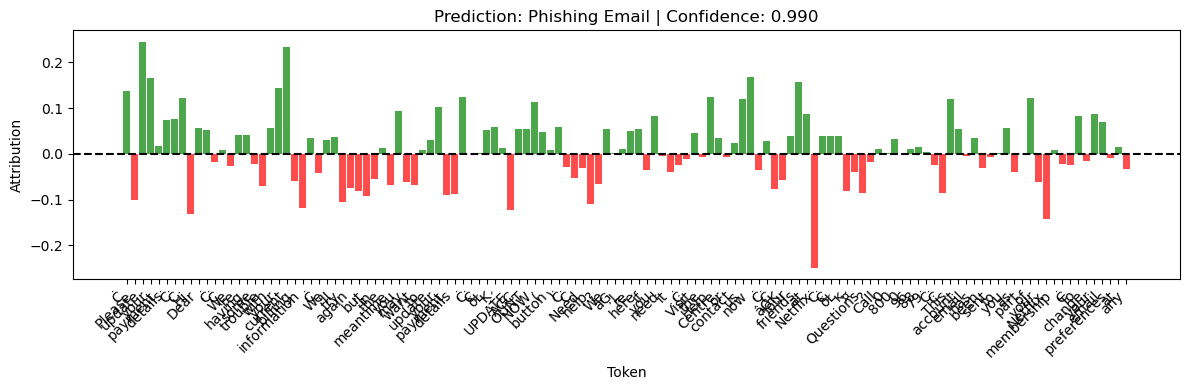

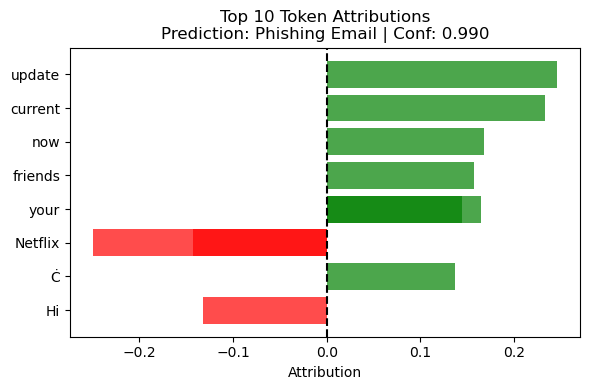

In [10]:
import torch
import torch.nn.functional as F
import numpy as np
from transformers import RobertaTokenizer, RobertaForSequenceClassification, RobertaConfig
from captum.attr import LayerIntegratedGradients
import matplotlib.pyplot as plt
from IPython.display import HTML, display

if MODEL_DIR == "":
    MODEL_DIR = "./roberta-model-xai"
try:
    config = RobertaConfig.from_pretrained(MODEL_DIR)
    tokenizer = RobertaTokenizer.from_pretrained(MODEL_DIR)
    model = RobertaForSequenceClassification.from_pretrained(MODEL_DIR, config=config)
except Exception:
    print('Model not found Error')
    exit() 

device = torch.device("cpu")
model.to(device)
model.eval()

class RoBERTaLIGAnalyzer:
    def __init__(self, model, tokenizer, device, max_length=128):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.max_length = max_length
        self.embedding_layer = model.roberta.embeddings.word_embeddings
        self.lig = LayerIntegratedGradients(self.forward_fn, self.embedding_layer)

    def forward_fn(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits

    def analyze(self, text, target_class=None, n_steps=50):
        enc = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=self.max_length
        )
        input_ids = enc["input_ids"].to(self.device)
        attention_mask = enc["attention_mask"].to(self.device)

        with torch.no_grad():
            logits = self.model(input_ids=input_ids, attention_mask=attention_mask).logits
            probs = F.softmax(logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()
        conf = probs[0, pred].item()
        if target_class is None:
            target_class = pred

        baseline_ids = torch.full_like(input_ids, self.tokenizer.pad_token_id)

        attributions, delta = self.lig.attribute(
            inputs=input_ids,
            baselines=baseline_ids,
            additional_forward_args=(attention_mask,),
            target=target_class,
            n_steps=n_steps,
            return_convergence_delta=True
        )

        token_attrs = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
        tokens = self.tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).cpu().tolist())

        return {
            "tokens": tokens,
            "attributions": token_attrs,
            "pred_class": pred,
            "confidence": conf,
            "delta": delta.item()
        }

    def plot_lig(self, tokens, attributions, pred_label, confidence, figsize=(12,4)):
        clean_tokens, clean_attrs = [], []
        for t, a in zip(tokens, attributions):
            if t not in [self.tokenizer.cls_token, self.tokenizer.sep_token, self.tokenizer.pad_token]:
                clean_tokens.append(t.replace("Ġ", ""))
                clean_attrs.append(a)
        colors = ["green" if v > 0 else "red" for v in clean_attrs]
        plt.figure(figsize=figsize)
        plt.bar(range(len(clean_tokens)), clean_attrs, color=colors, alpha=0.7)
        plt.xticks(range(len(clean_tokens)), clean_tokens, rotation=45, ha="right")
        plt.xlabel("Token")
        plt.ylabel("Attribution")
        plt.title(f"Prediction: {pred_label} | Confidence: {confidence:.3f}")
        plt.axhline(0, color="black", linestyle="--")
        plt.tight_layout()
        plt.show()

    def show_lig_html(self, tokens, attributions, pred_label, confidence):
        clean_tokens, clean_attrs = [], []
        for t, a in zip(tokens, attributions):
            if t not in [self.tokenizer.cls_token, self.tokenizer.sep_token, self.tokenizer.pad_token]:
                clean_tokens.append(t.replace("Ġ", " "))
                clean_attrs.append(a)
        arr = np.array(clean_attrs)
        norm = arr / (np.max(np.abs(arr)) + 1e-10)
        html = f"<div style='font-family:sans-serif; line-height:2; padding:10px; border:1px solid #ccc;'>"
        html += f"<b>Prediction: {pred_label} (Conf: {confidence:.3f})</b><br>"
        for tok, val in zip(clean_tokens, norm):
            r, g = (255, 0) if val < 0 else (0, 128)
            opacity = min(abs(val), 1.0) * 0.7
            html += f"<span style='background-color:rgba({r},{g},0,{opacity}); padding:2px 4px; margin:0 2px; border-radius:3px;'>{tok}</span>"
        html += "</div>"
        display(HTML(html))

    def plot_topk_lig(self, tokens, attributions, pred_label, confidence, top_k=10, figsize=(6,4)):
        clean = [(t.replace('Ġ', ''), float(a))
                 for t, a in zip(tokens, attributions)
                 if t not in [self.tokenizer.cls_token, self.tokenizer.sep_token, self.tokenizer.pad_token]]
        import pandas as pd
        df = pd.DataFrame(clean, columns=['token', 'attr'])
        df['abs_attr'] = df['attr'].abs()
        df_top = df.sort_values('abs_attr', ascending=False).head(top_k).iloc[::-1]
        colors = ['green' if v > 0 else 'red' for v in df_top['attr']]
        plt.figure(figsize=figsize)
        plt.barh(df_top['token'], df_top['attr'], color=colors, alpha=0.7)
        plt.xlabel('Attribution')
        plt.title(f"Top {top_k} Token Attributions\nPrediction: {pred_label} | Conf: {confidence:.3f}")
        plt.axvline(0, color='black', linestyle='--')
        plt.tight_layout()
        plt.show()

    def show_topk_lig_html(self, tokens, attributions, pred_label, confidence, top_k=10):
        clean = [(t.replace('Ġ', ' '), float(a))
                 for t, a in zip(tokens, attributions)
                 if t not in [self.tokenizer.cls_token, self.tokenizer.sep_token, self.tokenizer.pad_token]]
        import pandas as pd
        df = pd.DataFrame(clean, columns=['token', 'attr'])
        df['abs_attr'] = df['attr'].abs()
        df_top = df.sort_values('abs_attr', ascending=False).head(top_k)
        arr = df_top['attr'].values
        norm = arr / (np.max(np.abs(arr)) + 1e-10)
        html = f"<div style='font-family:sans-serif; line-height:2; padding:10px; border:1px solid #ccc;'>"
        html += f"<b>Prediction: {pred_label} (Conf: {confidence:.3f})</b><br>"
        for tok, val in zip(df_top['token'], norm):
            r, g = (255, 0) if val < 0 else (0, 128)
            opacity = min(abs(val), 1.0) * 0.7
            html += f"<span style='background-color:rgba({r},{g},0,{opacity}); padding:2px 4px; margin:0 4px; border-radius:3px;'>{tok}</span>"
        html += "</div>"
        display(HTML(html))

labels = {0: "Safe Email", 1: "Phishing Email"}
analyzer = RoBERTaLIGAnalyzer(model, tokenizer, device)

res = analyzer.analyze(sample_text)

analyzer.plot_lig(res["tokens"], res["attributions"], labels[res["pred_class"]], res["confidence"])
analyzer.show_lig_html(res["tokens"], res["attributions"], labels[res["pred_class"]], res["confidence"])
analyzer.plot_topk_lig(res["tokens"], res["attributions"], labels[res["pred_class"]], res["confidence"])
analyzer.show_topk_lig_html(res["tokens"], res["attributions"], labels[res["pred_class"]], res["confidence"])

## 10. Automated Phishing Detection with Explainability using RoBERTa + LIG


This module implements a **fully automated phishing email detection system** using a fine-tuned RoBERTa model with **Layer Integrated Gradients (LIG)** for model explainability. The system integrates real-time **Gmail monitoring**, **XAI attribution analysis**, **ChatGPT-based expert reporting**, and **Slack notifications** to alert users of phishing threats with interpretable explanations.

---

### 1. System Overview

| Component                  | Role                                                            |
| -------------------------- | --------------------------------------------------------------- |
| **RoBERTa + LIG (Captum)** | Token-level attribution for explainability                      |
| **OpenAI GPT-4o**          | Natural-language expert report generation                       |
| **Gmail API**              | Real-time email inbox monitoring                                |
| **Slack Webhook**          | Instant phishing alerts with rich context                       |
| **HTML Report Generator**  | Structured, visual report with token heatmap & confusion matrix |

---

### 2. logic flow 

The `main()` function:

* Periodically polls the Gmail inbox.
* For each new message:

  1. Decodes and parses the message.
  2. Runs RoBERTa + LIG attribution analysis.
  3. Generates a layman-level expert report via GPT-4o.
  4. Sends Slack alert if classified as phishing.
  5. Saves a full HTML+JSON report.

---


### 3. Core Class: `EnhancedRoBERTaXAI`

Encapsulates XAI logic on top of RoBERTa using Captum’s `LayerIntegratedGradients`:

* `__init__`: Loads model/tokenizer, configures Captum’s LIG.
* `_load_model`: Handles fallback to `roberta-base` if local model load fails.
* `analyze_email()`: Applies LIG to email text and returns token attributions, predicted class, and confidence.
* `_structure_analysis_result()`: Organizes output into token-wise influence, risk scores, and interpretability metrics.
* `_analyze_risk_signals()`: Heuristically evaluates phishing risk based on token-level cues (e.g., suspicious URLs, urgency words).
* `generate_expert_report()`: Leverages OpenAI API to write a layman-friendly explanation of model predictions.
* `save_comprehensive_report()`: Exports a complete HTML report with attribution heatmap and model metrics.
* `_generate_html_report()`: Visually integrates all components into a professional HTML file.

---

### 4. Wrapper Class: `PhishingXAIAnalyzer`

Simplifies end-to-end flow:

* `analyze_and_report()`: Runs LIG analysis → GPT-4o reporting → optional HTML report saving.

---

### 5. Integration Modules

* **Gmail API** (`get_gmail_service`): Authenticates and retrieves latest unread emails.
* **Slack Alert** (`send_phishing_alert_to_slack`): Sends phishing alert with GPT-4o summary and local report path.
* **Email Body Parser** (`get_email_body`): Extracts plaintext from email MIME parts.

---

This system demonstrates how **XAI techniques** can be seamlessly embedded into **real-world operational pipelines** (e.g., email security) with automated reporting and visualization, making model decisions transparent to both developers and non-technical stakeholders.

---

## 10. 설명 가능한 RoBERTa + LIG 기반 자동 피싱 탐지 시스템

이 모듈은 **Layer Integrated Gradients (LIG)** 기반의 설명 가능 인공지능(XAI)을 적용한, 파인튜닝된 RoBERTa 모델을 활용한 **완전 자동화 피싱 이메일 탐지 시스템**입니다. 본 시스템은 실시간 **Gmail 모니터링**, **XAI 기여도 분석**, **ChatGPT 기반 전문가 보고서 생성**, **Slack 알림**을 통합하여, 해석 가능한 설명과 함께 사용자에게 피싱 위협을 즉시 알립니다.

---

### 1. 시스템 개요

| 구성 요소                    | 역할                                                                 |
| --------------------------- | -------------------------------------------------------------------- |
| **RoBERTa + LIG (Captum)**  | 설명 가능성을 위한 토큰 단위 기여도 산출                              |
| **OpenAI GPT-4o**           | 자연어 기반 전문가 보고서 생성                                        |
| **Gmail API**               | 실시간 이메일 인박스 모니터링                                         |
| **Slack Webhook**           | 풍부한 맥락의 즉각적인 피싱 경고                                      |
| **HTML 보고서 생성기**      | 토큰 히트맵 및 혼동 행렬이 포함된 구조적 시각 보고서                   |

---

### 2. 동작 흐름 

`main()` 함수는 다음을 수행합니다:

* Gmail 인박스를 주기적으로 폴링
* 각 신규 메시지에 대해:
  1. 메시지 디코딩 및 파싱
  2. RoBERTa + LIG 기여도 분석 실행
  3. GPT-4o를 통한 비전문가용 전문가 보고서 생성
  4. 피싱으로 분류 시 Slack 알림 전송
  5. 전체 HTML+JSON 보고서 저장

---

### 3. 핵심 클래스: `EnhancedRoBERTaXAI`

Captum의 `LayerIntegratedGradients`를 활용하여 RoBERTa 위에 XAI 로직을 캡슐화합니다:

* `__init__`: 모델/토크나이저 로드 및 Captum LIG 설정
* `_load_model`: 로컬 모델 로드 실패 시 `roberta-base`로 폴백 처리
* `analyze_email()`: 이메일 텍스트에 LIG 적용, 토큰 기여도/예측 클래스/신뢰도 반환
* `_structure_analysis_result()`: 토큰별 영향력, 위험 점수, 해석성 지표 등 결과 구조화
* `_analyze_risk_signals()`: 토큰 단위 단서(예: 의심 URL, 긴급 단어) 기반 휴리스틱 피싱 위험 평가
* `generate_expert_report()`: OpenAI API로 모델 예측에 대한 비전문가용 설명 생성
* `save_comprehensive_report()`: 기여도 히트맵 및 모델 지표가 포함된 HTML 보고서 내보내기
* `_generate_html_report()`: 모든 구성요소를 시각적으로 통합한 전문 HTML 파일 생성

---

### 4. 래퍼 클래스: `PhishingXAIAnalyzer`

엔드-투-엔드 플로우를 단순화합니다:

* `analyze_and_report()`: LIG 분석 → GPT-4o 보고서 → (선택적) HTML 보고서 저장

---

### 5. 통합 모듈

* **Gmail API** (`get_gmail_service`): 인증 및 최신 미확인 이메일 조회
* **Slack 알림** (`send_phishing_alert_to_slack`): GPT-4o 요약 및 로컬 보고서 경로와 함께 피싱 경고 전송
* **이메일 본문 파서** (`get_email_body`): 이메일 MIME 파트에서 평문 추출

---



이 시스템은 **XAI 기법**이 **실제 운영 파이프라인**(예: 이메일 보안)에 자동 보고 및 시각화와 함께 어떻게 자연스럽게 내장될 수 있는지 보여주며, 모델의 의사결정을 개발자와 비전문가 모두에게 투명하게 만듭니다.

---

In [13]:
# TODO input openai api key, slack webhook url, gmail credentials path 

# OpenAI API key
OPENAI_API_KEY = "" # TODO input openai api key

# Slack weebhook URL
SLACK_WEBHOOK_URL = "" # TODO input slack webhook url 

# Gmail API "credentials.json" file path  
GMAIL_CREDENTIALS_PATH = "" # TODO input gmail credentials path 

# Check interval seconds
CHECK_INTERVAL_SECONDS = 10

In [17]:
import torch
import torch.nn.functional as F
import numpy as np
from transformers import RobertaTokenizer, RobertaForSequenceClassification, RobertaConfig
from captum.attr import LayerIntegratedGradients
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from typing import Tuple, List, Dict, Any
import openai
import json
import requests
from datetime import datetime, timezone, timedelta
import os
from dataclasses import dataclass
import io
import base64
import time
from email import message_from_bytes
from google.oauth2.credentials import Credentials
from google_auth_oauthlib.flow import InstalledAppFlow
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError


@dataclass
class XAIConfig:
    openai_api_key: str
    model_dir: str = "./roberta-model-xai"
    max_length: int = 128
    n_steps: int = 50
    output_dir: str = "./xai_reports"

class EnhancedRoBERTaXAI:
    def __init__(self, config: XAIConfig):
        self.config = config
        self.device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
        self.labels = {0: "정상 이메일", 1: "피싱 이메일"}
        self.client = openai.OpenAI(api_key=config.openai_api_key)
        os.makedirs(config.output_dir, exist_ok=True)
        self._load_model()
        self.embedding_layer = self.model.roberta.embeddings.word_embeddings
        self.lig = LayerIntegratedGradients(self.forward_fn, self.embedding_layer)

    def _load_model(self):
        try:
            model_config = RobertaConfig.from_pretrained(self.config.model_dir, output_attentions=True)
            self.tokenizer = RobertaTokenizer.from_pretrained(self.config.model_dir)
            self.model = RobertaForSequenceClassification.from_pretrained(
                self.config.model_dir, config=model_config
            )
            print(f"✅ 로컬 모델 '{self.config.model_dir}' 로딩 성공.")
        except Exception:
            print(f"⚠️ 로컬 모델 '{self.config.model_dir}' 로딩 실패. 'roberta-base' 모델을 대신 사용합니다.")
            self.config.model_dir = "roberta-base"
            model_config = RobertaConfig.from_pretrained(self.config.model_dir, num_labels=2, output_attentions=True)
            self.tokenizer = RobertaTokenizer.from_pretrained(self.config.model_dir)
            self.model = RobertaForSequenceClassification.from_pretrained(
                self.config.model_dir, config=model_config
            )
        self.model.to(self.device)
        self.model.eval()

    def forward_fn(self, input_ids, attention_mask):
        return self.model(input_ids=input_ids, attention_mask=attention_mask).logits

    def analyze_email(self, email_text: str, target_class: int = None) -> Dict[str, Any]:
        enc = self.tokenizer(
            email_text, return_tensors="pt", truncation=True, padding="max_length", max_length=self.config.max_length
        )
        input_ids = enc["input_ids"].to(self.device)
        attention_mask = enc["attention_mask"].to(self.device)

        with torch.no_grad():
            logits = self.model(input_ids=input_ids, attention_mask=attention_mask).logits
            probs = F.softmax(logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()
        conf = probs[0, pred].item()

        if target_class is None:
            target_class = pred
        
        baseline_ids = torch.full_like(input_ids, self.tokenizer.pad_token_id)
        attributions, delta = self.lig.attribute(
            inputs=input_ids, baselines=baseline_ids, additional_forward_args=(attention_mask,),
            target=target_class, n_steps=self.config.n_steps, return_convergence_delta=True
        )
        token_attrs = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
        tokens = self.tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).cpu().tolist())

        return self._structure_analysis_result(
            email_text, tokens, token_attrs, pred, conf, delta.item(), probs[0].cpu().numpy()
        )

    def _structure_analysis_result(self, email_text: str, tokens: List[str],
                                   attributions: np.ndarray, prediction: int,
                                   confidence: float, delta: float,
                                   all_probs: np.ndarray) -> Dict[str, Any]:
        clean_analysis = []
        for token, attr in zip(tokens, attributions):
            if token not in ['<s>', '</s>', '<pad>']:
                clean_token = token.replace('Ġ', '')
                clean_analysis.append({"token": clean_token, "attribution": float(attr)})

        sorted_by_magnitude = sorted(clean_analysis, key=lambda x: abs(x["attribution"]), reverse=True)
        positive_tokens = [item for item in clean_analysis if item["attribution"] > 0]
        negative_tokens = [item for item in clean_analysis if item["attribution"] < 0]
        influential_tokens_for_risk = positive_tokens if prediction == 1 else negative_tokens
        risk_signals = self._analyze_risk_signals(email_text, influential_tokens_for_risk)

        return {
            "email_text": email_text,
            "prediction": {
                "class": prediction, "label": self.labels[prediction], "confidence": float(confidence),
                "all_class_probabilities": {"정상 이메일": float(all_probs[0]), "피싱 이메일": float(all_probs[1])}
            },
            "token_analysis": {"all_tokens": clean_analysis, "most_influential": sorted_by_magnitude[:15]},
            "risk_assessment": risk_signals,
            "model_metrics": {"analysis_timestamp": datetime.now().isoformat()}
        }

    def _analyze_risk_signals(self, email_text: str, influential_tokens: List[Dict]) -> Dict[str, Any]:
        import re
        phishing_keywords = ['click', 'urgent', 'immediately', 'verify', 'account', 'suspended', 'confirm', 'update', 'secure', 'login', 'password', 'bank', 'paypal', 'amazon', 'apple', 'microsoft', 'security', 'alert']
        urls = re.findall(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', email_text)
        suspicious_domains = [url for url in urls if any(domain in url.lower() for domain in ['bit.ly', 'tinyurl', 'fake', 'secure-verify'])]
        risky_influential_tokens = [token_info for token_info in influential_tokens[:10] if any(keyword in token_info['token'].lower() for keyword in phishing_keywords)]
        urgency_indicators = [token for token in influential_tokens if any(urgent in token['token'].lower() for urgent in ['urgent', 'immediate', 'now', 'asap'])]
        return {
            "suspicious_urls": urls, "potential_fake_domains": suspicious_domains,
            "risky_influential_keywords": risky_influential_tokens, "urgency_indicators": urgency_indicators,
            "overall_risk_score": len(risky_influential_tokens) + len(suspicious_domains) + len(urgency_indicators)
        }

    def generate_expert_report(self, analysis_result: Dict[str, Any]) -> str:
        prompt = self._create_expert_prompt(analysis_result)
        try:
            response = self.client.chat.completions.create(
                model="gpt-4o",
                messages=[
                    {"role": "system", "content": "당신은 사이버보안 전문가입니다. 피싱 이메일 분석 결과를 바탕으로, IT 지식이 없는 일반 사용자도 쉽게 이해할 수 있도록 명확하고 간결한 보고서를 작성해야 합니다."},
                    {"role": "user", "content": prompt}
                ],
                max_tokens=2000, temperature=0.2
            )
            return response.choices[0].message.content
        except Exception as e:
            return f"보고서 생성 중 오류가 발생했습니다: {str(e)}"

    def _create_expert_prompt(self, analysis_result: Dict[str, Any]) -> str:
        prediction_info = analysis_result["prediction"]
        token_analysis = analysis_result["token_analysis"]
        return f"""
다음은 AI 모델이 분석한 이메일의 기술적인 데이터입니다. 이 데이터를 바탕으로 아래 요청사항에 맞춰 사용자 보고서를 작성해주세요.

## 분석 대상 이메일:
"{analysis_result['email_text'][:500]}..."

## AI 모델 예측 결과:
- 예측: {prediction_info['label']} (신뢰도: {prediction_info['confidence']:.2%})
- AI가 예측에 중요하다고 판단한 단어(상위 5개): {[item['token'] for item in token_analysis['most_influential'][:5]]}

## 요청사항:
일반 사용자가 쉽게 이해할 수 있도록 다음 항목에 맞춰 간결하게 설명해주세요:

1. **간단한 결론**: 이 이메일이 위험한지 여부와 그 판단의 간단한 이유
2. **모델이 판단한 근거**: 제가 보낸 LIG 결과 데이터를 근거로 모델이 판단한 이유를 정확하고 구체적이고 자세하게 설명해주세요.
3. **행동 가이드**: 이 이메일을 받았을 때 해야 할 행동 (예: 삭제, 보안팀 신고 등)
4. **예방 팁**: 비슷한 피싱 이메일을 어떻게 구별하면 좋을지, 평소 어떤 점을 주의해야 하는지

기술 용어는 최대한 배제하고, 일반적인 직장인이 이해할 수 있는 표현으로 작성해주세요.
"""

    def save_comprehensive_report(self, email_text: str, analysis_result: Dict[str, Any], expert_report: str, filename_prefix: str = "phishing_analysis") -> str:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{filename_prefix}_{timestamp}.html"
        filepath = os.path.join(self.config.output_dir, filename)
        html_content = self._generate_html_report(email_text, analysis_result, expert_report)
        with open(filepath, 'w', encoding='utf-8') as f:
            f.write(html_content)

        json_filename = f"{filename_prefix}_{timestamp}.json"
        json_filepath = os.path.join(self.config.output_dir, json_filename)
        with open(json_filepath, 'w', encoding='utf-8') as f:
            json.dump(analysis_result, f, ensure_ascii=False, indent=2)
            
        return os.path.abspath(filepath)

    @staticmethod
    def _get_model_performance_vis() -> Tuple[str, str]:
        report_text = "[RoBERTa] Test Results\n\nAccuracy : 0.9863\nF1 Score (Phishing class=1) : 0.9817\n\nClassification Report:\n              precision    recall  f1-score   support\n    Safe (0)       0.99      0.99      0.99      2197\nPhishing (1)       0.98      0.98      0.98      1311\n\n    accuracy                           0.99      3508\n   macro avg       0.99      0.99      0.99      3508\nweighted avg       0.99      0.99      0.99      3508\n"
        cm = np.array([[2172, 25], [23, 1288]])
        fig, ax = plt.subplots(figsize=(6, 5))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Safe (0)", "Phishing (1)"])
        disp.plot(ax=ax, cmap='viridis', colorbar=True)
        ax.set_title("Confusion Matrix - RoBERTa")
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight')
        plt.close(fig)
        img_base64 = base64.b64encode(buf.getvalue()).decode('utf-8')
        return report_text, f"data:image/png;base64,{img_base64}"

    def _visualize_attributions_as_html(self, analysis_result: Dict[str, Any]) -> str:
        tokens_data = analysis_result['token_analysis']['all_tokens']
        prediction_class = analysis_result['prediction']['class']
        max_abs_attr = max(abs(d['attribution']) for d in tokens_data) if tokens_data else 1.0
        html_parts = []
        for item in tokens_data:
            token, attr = item['token'], item['attribution']
            if (prediction_class == 1 and attr > 0) or (prediction_class == 0 and attr < 0):
                color, text_color = (255, 192, 203), "#a00"
            elif (prediction_class == 1 and attr < 0) or (prediction_class == 0 and attr > 0):
                color, text_color = (173, 216, 230), "#006"
            else:
                color, text_color = (240, 240, 240), "#555"
            opacity = min(max(0.1, abs(attr) / max_abs_attr), 1.0)
            space = ' ' if not token.startswith(('#', '.')) else ''
            html_parts.append(f'<span title="Attribution: {attr:.4f}" style="background-color: rgba({color[0]},{color[1]},{color[2]},{opacity}); color: {text_color}; padding: 2px 4px; border-radius: 3px; margin: 1px;">{token}</span>{space}')
        return "".join(html_parts)

    def _generate_html_report(self, email_text: str, analysis_result: Dict[str, Any], expert_report: str) -> str:
        import markdown
        prediction = analysis_result["prediction"]
        risk_color = "#d32f2f" if prediction["class"] == 1 else "#388e3c"
        perf_report_text, conf_matrix_img_src = self._get_model_performance_vis()
        attribution_heatmap_html = self._visualize_attributions_as_html(analysis_result)
        perf_report_html = markdown.markdown(perf_report_text, extensions=['tables', 'fenced_code'])
        return f"""
<!DOCTYPE html><html lang="ko"><head><meta charset="UTF-8"><title>피싱 이메일 탐지 XAI 분석 보고서</title><style>
body{{font-family:'Malgun Gothic',sans-serif;margin:20px;background-color:#f8f9fa;}}
.container{{max-width:1200px;margin:auto;background:white;padding:30px;border-radius:12px;box-shadow:0 4px 20px rgba(0,0,0,0.08);}}
h1,h2,h3{{color:#333;}}
.prediction-box{{background:linear-gradient(135deg,{risk_color},{risk_color}b3);color:white;padding:25px;border-radius:10px;margin:20px 0;text-align:center;}}
.section{{margin:35px 0;padding:25px;border-left:5px solid #007bff;background-color:#fdfdff;}}
.expert-report{{background-color:#e9f5ff;padding:25px;border:1px solid #bde0fe;border-radius:8px;white-space:pre-wrap;word-wrap:break-word;line-height:1.7;}}
.email-content,.attribution-heatmap{{background:#fff;padding:20px;border-radius:8px;border:1px solid #eee;line-height:2.0;}}
pre{{white-space:pre-wrap;word-wrap:break-word;background-color:#e9ecef;padding:15px;border-radius:5px;}}
.performance-section{{display:flex;gap:20px;align-items:flex-start;flex-wrap:wrap;}}
.performance-section img{{max-width:100%;}}
.performance-markdown {{background-color:#f8f9fa;padding:10px 15px;border-radius:6px;overflow-x:auto;}}
.performance-markdown table{{border-collapse:collapse;width:100%;margin-top:10px;}}
.performance-markdown th, .performance-markdown td{{border:1px solid #bbb;padding:6px 10px;text-align:center;}}
.performance-markdown th{{background:#e3eafc;}}
.performance-markdown code{{background:#e9ecef;padding:2px 4px;border-radius:3px;}}
</style></head>
<body>
<div class="container">
    <h1>🛡️ 피싱 이메일 탐지 XAI 분석 보고서</h1>
    <p>생성 시간: {analysis_result['model_metrics']['analysis_timestamp']}</p>
    <div class="prediction-box">
        <h2>🎯 모델 예측 결과: {prediction['label']}</h2>
        <p style="font-size:18px;">신뢰도: {prediction['confidence']:.1%}</p>
    </div>
    <div class="section">
        <h3>🎓 전문가 자동 분석 보고서 (Powered by GPT-4o)</h3>
        <div class="expert-report">{expert_report}</div>
    </div>
    <div class="section">
        <h3>📧 분석 대상 이메일 원문</h3>
        <div class="email-content"><pre>{email_text}</pre></div>
    </div>
    <div class="section">
        <h3>🔍 AI의 판단 근거 시각화 (Attribution Heatmap)</h3>
        <p><strong style="color: #a00;">붉은색</strong>에 가까울수록 예측에 강한 영향을 미쳤음을 의미합니다.</p>
        <div class="attribution-heatmap">{attribution_heatmap_html}</div>
    </div>
    <div class="section">
        <h3>📊 모델 성능 분석</h3>
        <div class="performance-section">
            <div style="flex:1;">
                <div class="performance-markdown">{perf_report_html}</div>
            </div>
            <div style="flex:1;text-align:center;">
                <h4>혼동 행렬</h4>
                <img src="{conf_matrix_img_src}" alt="Confusion Matrix">
            </div>
        </div>
    </div>
</div>
</body></html>
"""

class PhishingXAIAnalyzer:
    def __init__(self, openai_api_key: str):
        self.config = XAIConfig(openai_api_key=openai_api_key)
        self.analyzer = EnhancedRoBERTaXAI(self.config)

    def analyze_and_report(self, email_text: str, save_report: bool = True) -> Dict[str, Any]:
        print("1️⃣ Layer Integrated Gradients 분석 중...")
        analysis_result = self.analyzer.analyze_email(email_text)
        prediction = analysis_result["prediction"]
        print(f"  - 예측: {prediction['label']} (신뢰도: {prediction['confidence']:.1%})")
        print("2️⃣ ChatGPT 사용자 친화적 보고서 생성 중...")
        expert_report = self.analyzer.generate_expert_report(analysis_result)
        print("  - 보고서 생성 완료")
        report_path = None
        if save_report:
            print("3️⃣ 종합 HTML 보고서 저장 중...")
            report_path = self.analyzer.save_comprehensive_report(
                email_text, analysis_result, expert_report
            )
            print(f"  - 보고서 저장 완료: {report_path}")
        return {
            "analysis_result": analysis_result,
            "expert_report": expert_report,
            "report_path": report_path
        }

def get_gmail_service():
    SCOPES = ['https://www.googleapis.com/auth/gmail.readonly']
    creds = None
    if os.path.exists('token.json'):
        creds = Credentials.from_authorized_user_file('token.json', SCOPES)
    else:
        flow = InstalledAppFlow.from_client_secrets_file(GMAIL_CREDENTIALS_PATH, SCOPES)
        creds = flow.run_local_server(port=0)
        with open('token.json', 'w') as token:
            token.write(creds.to_json())
    return build('gmail', 'v1', credentials=creds)

def send_phishing_alert_to_slack(analysis_result: Dict, expert_report: str, report_path: str, email_subject: str, email_sender: str):
    prediction = analysis_result['prediction']
    report_summary = "\n".join(expert_report.split('\n\n')[:3])
    message = {
        "blocks": [
            {
                "type": "header",
                "text": {
                    "type": "plain_text",
                    "text": "🚨 피싱 이메일 감지 및 자동 분석 보고",
                    "emoji": True
                }
            },
            {
                "type": "section",
                "fields": [
                    {"type": "mrkdwn", "text": f"*From:*\n`{email_sender}`"},
                    {"type": "mrkdwn", "text": f"*Subject:*\n{email_subject}"}
                ]
            },
            {"type": "divider"},
            {
                "type": "section",
                "text": {
                    "type": "mrkdwn",
                    "text": f"🧠 *AI 분석 결과*: `{prediction['label']}` (신뢰도: *{prediction['confidence']:.1%}*)"
                }
            },
            {
                "type": "section",
                "text": {
                    "type": "mrkdwn",
                    "text": f"📜 *전문가 보고서 요약 (by GPT-4o):*\n>>>```{report_summary}```"
                }
            },
            {"type": "divider"},
            {
                "type": "section",
                "text": {
                    "type": "mrkdwn",
                    "text": f"💾 *전체 분석 보고서가 서버에 저장되었습니다.*\n*위치*: `{report_path}`"
                }
            }
        ]
    }
    response = requests.post(SLACK_WEBHOOK_URL, json=message)
    if response.status_code == 200:
        print("✅ Slack 알림 전송 완료")
    else:
        print(f"❌ Slack 알림 전송 실패: {response.status_code}, {response.text}")

def get_email_body(email_msg):
    body = ""
    if email_msg.is_multipart():
        for part in email_msg.walk():
            ctype = part.get_content_type()
            cdispo = str(part.get('Content-Disposition'))
            if ctype == 'text/plain' and 'attachment' not in cdispo:
                body = part.get_payload(decode=True).decode(errors='ignore')
                break
    else:
        body = email_msg.get_payload(decode=True).decode(errors='ignore')
    return body

def main():
    if OPENAI_API_KEY == "" or SLACK_WEBHOOK_URL == '':
        print("🚨 경고: OpenAI API 키와 Slack Webhook URL을 설정해야 합니다.")
        print("   - `OPENAI_API_KEY`와 `SLACK_WEBHOOK_URL` 변수를 수정해주세요.")
        return

    print("🚀 피싱 이메일 실시간 탐지 시스템을 시작합니다.")
    print("   - Gmail 연동 및 AI 분석기 초기화 중...")

    gmail_service = get_gmail_service()
    if not gmail_service:
        print("❌ Gmail 서비스 초기화에 실패했습니다. 프로그램을 종료합니다.")
        return

    xai_analyzer = PhishingXAIAnalyzer(openai_api_key=OPENAI_API_KEY)
    last_check_time = datetime.now(timezone.utc)
    print(f"✅ 초기화 완료. [{last_check_time.strftime('%Y-%m-%d %H:%M:%S')}] 이후의 새 메일을 감시합니다.")

    while True:
        try:
            result = gmail_service.users().messages().list(userId='me', maxResults=10).execute()
            messages = result.get('messages', [])

            if not messages:
                print("  - 새로운 이메일이 없습니다.")
                print(f"\n다음 확인까지 {CHECK_INTERVAL_SECONDS}초 대기합니다...")
                time.sleep(CHECK_INTERVAL_SECONDS)
                continue
            else:
                print(f"📩 {len(messages)}개의 최근 이메일을 확인합니다. 분석을 시작합니다.")
                found_new_mail = False
                for msg_meta in reversed(messages):
                    msg_id = msg_meta['id']
                    try:
                        msg = gmail_service.users().messages().get(userId='me', id=msg_id, format='raw').execute()
                        internal_date = int(msg.get('internalDate', '0')) // 1000
                        received_time = datetime.fromtimestamp(internal_date, tz=timezone.utc)
                        if received_time <= last_check_time:
                            continue

                        raw_msg = base64.urlsafe_b64decode(msg['raw'].encode('ASCII'))
                        email_msg = message_from_bytes(raw_msg)

                        subject = str(email_msg['Subject'])
                        sender = str(email_msg['From'])
                        body = get_email_body(email_msg)

                        if not body:
                            print(f"  - [Msg ID: {msg_id}] 본문이 없어 건너뜁니다.")
                            continue

                        print(f"\n--- [분석 시작] From: {sender}, Subject: {subject} ---")
                        report_data = xai_analyzer.analyze_and_report(email_text=body)
                        is_phishing = report_data["analysis_result"]["prediction"]["class"] == 1
                        if is_phishing:
                            print("🚨 피싱으로 판단되어 Slack 알림을 전송합니다.")
                            send_phishing_alert_to_slack(
                                analysis_result=report_data["analysis_result"],
                                expert_report=report_data["expert_report"],
                                report_path=report_data["report_path"],
                                email_subject=subject,
                                email_sender=sender
                            )
                        else:
                            print("✅ 정상 메일로 판단되었습니다.")

                        print(f"--- [분석 완료] Msg ID: {msg_id} ---")
                        found_new_mail = True
                        break

                    except HttpError as error:
                        print(f"  - ❌ 이메일(ID: {msg_id}) 처리 중 오류 발생: {error}")
                    except Exception as e:
                        print(f"  - ❌ 예기치 않은 오류 발생 (ID: {msg_id}): {e}")

                if not found_new_mail:
                    print("  - 서버 실행 이후 도착한 새 이메일이 없습니다.")
                    print(f"\n다음 확인까지 {CHECK_INTERVAL_SECONDS}초 대기합니다...")
                    time.sleep(CHECK_INTERVAL_SECONDS)
                    continue
                else: 
                    break

            print(f"\n다음 확인까지 {CHECK_INTERVAL_SECONDS}초 대기합니다...")
            time.sleep(CHECK_INTERVAL_SECONDS)

        except HttpError as error:
            print(f"❌ Gmail API 호출 중 오류 발생: {error}")
            time.sleep(60)
        except Exception as e:
            print(f"❌ 메인 루프에서 예기치 않은 오류 발생: {e}")
            time.sleep(60)

if __name__ == "__main__":
    main()

🚀 피싱 이메일 실시간 탐지 시스템을 시작합니다.
   - Gmail 연동 및 AI 분석기 초기화 중...
✅ 로컬 모델 './roberta-model-xai' 로딩 성공.
✅ 초기화 완료. [2025-06-11 09:49:15] 이후의 새 메일을 감시합니다.
📩 10개의 최근 이메일을 확인합니다. 분석을 시작합니다.
  - 서버 실행 이후 도착한 새 이메일이 없습니다.

다음 확인까지 10초 대기합니다...
📩 10개의 최근 이메일을 확인합니다. 분석을 시작합니다.
  - 서버 실행 이후 도착한 새 이메일이 없습니다.

다음 확인까지 10초 대기합니다...
📩 10개의 최근 이메일을 확인합니다. 분석을 시작합니다.
  - ❌ 이메일(ID: 1975e653e3ebd98a) 처리 중 오류 발생: <HttpError 404 when requesting https://gmail.googleapis.com/gmail/v1/users/me/messages/1975e653e3ebd98a?format=raw&alt=json returned "Requested entity was not found.". Details: "[{'message': 'Requested entity was not found.', 'domain': 'global', 'reason': 'notFound'}]">
  - 서버 실행 이후 도착한 새 이메일이 없습니다.

다음 확인까지 10초 대기합니다...
📩 10개의 최근 이메일을 확인합니다. 분석을 시작합니다.

--- [분석 시작] From: =?UTF-8?B?67CV7ZiE66+8?= <hyunmins4287@gmail.com>, Subject: Your account is hold. ---
1️⃣ Layer Integrated Gradients 분석 중...
  - 예측: 피싱 이메일 (신뢰도: 99.6%)
2️⃣ ChatGPT 사용자 친화적 보고서 생성 중...
  - 보고서 생성 완료
3️⃣ 종합 HTML 보고서 저장 중...
  - 보고서 저